## 序列到序列学习(seq2seq)

遵循编码器－解码器架构的设计原则， 循环神经网络编码器使用长度可变的序列作为输入， 将其转换为固定形状的隐状态。 换言之，输入序列的信息被编码到循环神经网络编码器的隐状态中。 为了连续生成输出序列的词元， 独立的循环神经网络解码器是基于输入序列的编码信息 和输出序列已经看见的或者生成的词元来预测下一个词元。

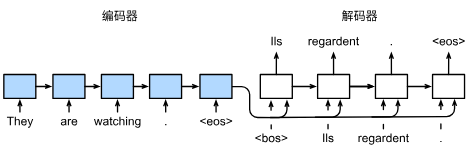

在图中， 特定的“<eos>”表示序列结束词元。 一旦输出序列生成此词元，模型就会停止预测。 在循环神经网络解码器的初始化时间步，有两个特定的设计决定： 首先，特定的“<bos>”表示序列开始词元，它是解码器的输入序列的第一个词元。 其次，使用循环神经网络编码器最终的隐状态来初始化解码器的隐状态。

下面，动手构建图中的设计

### 编码器

编码器的作用是把一个不定长的输入序列变换成一个定长的背景变量$\boldsymbol{c}$，并在该背景变量中编码输入序列信息。常用的编码器是循环神经网络。
让我们考虑批量大小为1的时序数据样本。假设输入序列是$x_1,\ldots,x_T$，例如$x_i$是输入句子中的第$i$个词。在时间步$t$，循环神经网络将输入$x_t$的特征向量$\boldsymbol{x}_t$和上个时间步的隐藏状态$\boldsymbol{h}_{t-1}$变换为当前时间步的隐藏状态$\boldsymbol{h}_t$。我们可以用函数$f$表达循环神经网络隐藏层的变换：

$$
\boldsymbol{h}_t = f(\boldsymbol{x}_t, \boldsymbol{h}_{t-1}).
$$

接下来，编码器通过自定义函数$q$将各个时间步的隐藏状态变换为背景变量

$$
\boldsymbol{c} =  q(\boldsymbol{h}_1, \ldots, \boldsymbol{h}_T).
$$

例如，当选择$q(\boldsymbol{h}_1, \ldots, \boldsymbol{h}_T) = \boldsymbol{h}_T$时，背景变量是输入序列最终时间步的隐藏状态$\boldsymbol{h}_T$。

以上描述的编码器是一个单向的循环神经网络，每个时间步的隐藏状态只取决于该时间步及之前的输入子序列。我们也可以使用双向循环神经网络构造编码器。在这种情况下，编码器每个时间步的隐藏状态同时取决于该时间步之前和之后的子序列（包括当前时间步的输入），并编码了整个序列的信息。


In [1]:
import collections
import math
import torch
from torch import nn
from d2l import torch as d2l

class Seq2SeqEncoder(nn.Module):
    """用于序列到序列学习的循环神经网络编码器"""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        ## 嵌入层
        self.embedding = nn.Embedding(vocab_size, embed_size)
        ## 编码层
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers,
                          dropout=dropout)
        
    def forward(self, X, *args):
        # 输出X的形状：(batch_size,num_steps,embed_size)
        X = self.embedding(X)
        # 在循环神经网络模型中，第一个轴对应于时间步
        X = X.permute(1, 0, 2) # 重新排列张量维度，第一二个互换
        # 如果未提及状态，则默认为0
        output,state = self.rnn(X)
        # output的形状:(num_steps,batch_size,num_hiddens)
        # state的形状:(num_layers,batch_size,num_hiddens)
        return output,state
    


下面，我们实例化上述编码器的实现： 我们使用一个两层门控循环单元编码器，其隐藏单元数为16,给定一小批量的输入序列X（批量大小为4,时间步为7）。 在完成所有时间步后， 最后一层的隐状态的输出是一个张量（output由编码器的循环层返回）， 其形状为（时间步数，批量大小，隐藏单元数）。

In [3]:
encoder = Seq2SeqEncoder(vocab_size=10,embed_size=8,num_hiddens=16,num_layers=2)

encoder.eval()
X = torch.zeros((4, 7),dtype=torch.long)
output,state = encoder(X)
output.shape

torch.Size([7, 4, 16])

由于这里使用的是门控循环单元， 所以在最后一个时间步的多层隐状态的形状是 （隐藏层的数量，批量大小，隐藏单元的数量）。 如果使用长短期记忆网络，state中还将包含记忆单元信息。

In [4]:
state.shape

torch.Size([2, 4, 16])

### 解码器

编码器输出的背景变量$\boldsymbol{c}$编码了整个输入序列$x_1, \ldots, x_T$的信息。给定训练样本中的输出序列$y_1, y_2, \ldots, y_{T'}$，对每个时间步$t'$（符号与输入序列或编码器的时间步$t$有区别），解码器输出$y_{t'}$的条件概率将基于之前的输出序列$y_1,\ldots,y_{t'-1}$和背景变量$\boldsymbol{c}$，即$P(y_{t'} \mid y_1, \ldots, y_{t'-1}, \boldsymbol{c})$。

为此，我们可以使用另一个循环神经网络作为解码器。在输出序列的时间步$t^\prime$，解码器将上一时间步的输出$y_{t^\prime-1}$以及背景变量$\boldsymbol{c}$作为输入，并将它们与上一时间步的隐藏状态$\boldsymbol{s}_{t^\prime-1}$变换为当前时间步的隐藏状态$\boldsymbol{s}_{t^\prime}$。因此，我们可以用函数$g$表达解码器隐藏层的变换：

$$
\boldsymbol{s}_{t^\prime} = g(y_{t^\prime-1}, \boldsymbol{c}, \boldsymbol{s}_{t^\prime-1}).
$$

有了解码器的隐藏状态后，我们可以使用自定义的输出层和softmax运算来计算$P(y_{t^\prime} \mid y_1, \ldots, y_{t^\prime-1}, \boldsymbol{c})$，例如，基于当前时间步的解码器隐藏状态 $\boldsymbol{s}_{t^\prime}$、上一时间步的输出$y_{t^\prime-1}$以及背景变量$\boldsymbol{c}$来计算当前时间步输出$y_{t^\prime}$的概率分布。



In [5]:
class Seq2SeqDecoder(d2l.Decoder):
    """用于序列到序列学习的循环神经网络解码器"""
    def __init__(self,vocab_size, embed_size, num_hiddens, num_layers,dropout=0, **kwargs):
        super(Seq2SeqDecoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 在每个时间步，解码器需要根据当前的输入词和上下文信息来生成输出，以便在生成过程中综合考虑源语言句子的语义信息以及当前时间步的输入
        # 前时间步的输入词的嵌入向量（embed_size维）上下文信息（num_hiddens维）
        self.rnn = nn.GRU(embed_size+ num_hiddens,num_hiddens, num_layers,
                          dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)
    
    def init_state(self, enc_outputs, *args):
        return enc_outputs[1]
    
    def forward(self, X, state):
        # 输出'X'的形状：(batch_size,num_steps,embed_size)
        X = self.embedding(X).permute(1, 0, 2)
        # 广播context，使其具有与X相同的num_steps
        context = state[-1].repeat(X.shape[0], 1, 1)
        X_and_context = torch.cat((X, context), dim=2)
        output, state = self.rnn(X_and_context, state)
        output = self.dense(output).permute(1, 0, 2)
        # output的形状:(batch_size,num_steps,vocab_size)
        # state的形状:(num_layers,batch_size,num_hiddens)
        return output, state

下面，我们用与前面提到的编码器中相同的超参数来实例化解码器。 如我们所见，解码器的输出形状变为（批量大小，时间步数，词表大小）， 其中张量的最后一个维度存储预测的词元分布。

In [6]:
decoder = Seq2SeqDecoder(vocab_size=10,embed_size=8,num_hiddens=16,num_layers=2)
decoder.eval()
state = decoder.init_state(encoder(X))
output,state = decoder(X,state)

output.shape,state.shape

(torch.Size([4, 7, 10]), torch.Size([2, 4, 16]))

上述循环神经网络“编码器－解码器”模型中的各层如图所示:

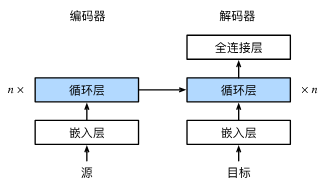

###  损失函数

在每个时间步，解码器预测了输出词元的概率分布。 类似于语言模型，可以使用softmax来获得分布， 并通过计算交叉熵损失函数来进行优化。但是，我们应该将填充词元的预测排除在损失函数的计算之外。

为此，我们可以使用下面的sequence_mask函数 通过零值化屏蔽不相关的项， 以便后面任何不相关预测的计算都是与零的乘积，结果都等于零。 例如，如果两个序列的有效长度（不包括填充词元）分别为1和2， 则第一个序列的第一项和第二个序列的前两项之后的剩余项将被清除为零。


In [7]:
def sequence_mask(X, valid_len,value=0):
    """在序列中屏蔽不相关的项"""
    maxlen = X.size(1)
    # valid_len[:, None] 将有效长度转换为形状为 (batch_size, 1) 的张量
    # 然后通过 < 运算符生成一个布尔类型的掩码张量。掩码张量的形状是 (batch_size, maxlen)，
    # 其中的元素为 True 或 False，表示对应位置是否需要保留
    mask = torch.arange((maxlen), dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]

    X[~mask] = value # 使用掩码对输入序列 X 进行屏蔽，将掩码中为 False 的位置对应的元素替换为指定的屏蔽值 value
    return X

X = torch.tensor([[1, 2, 3], [4, 5, 6]])
sequence_mask(X,torch.tensor([1, 2]))
                                                                                                                          

tensor([[1, 0, 0],
        [4, 5, 0]])

In [9]:
X = torch.ones(2, 3, 4)
sequence_mask(X, torch.tensor([1, 2]), value=-1)

tensor([[[ 1.,  1.,  1.,  1.],
         [-1., -1., -1., -1.],
         [-1., -1., -1., -1.]],

        [[ 1.,  1.,  1.,  1.],
         [ 1.,  1.,  1.,  1.],
         [-1., -1., -1., -1.]]])

现在，我们可以通过扩展softmax交叉熵损失函数来遮蔽不相关的预测。 最初，所有预测词元的掩码都设置为1。 一旦给定了有效长度，与填充词元对应的掩码将被设置为0。 最后，将所有词元的损失乘以掩码，以过滤掉损失中填充词元产生的不相关预测。

In [10]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带遮蔽的softmax交叉熵损失函数"""
    # pred的形状：(batch_size,num_steps,vocab_size)
    # label的形状：(batch_size,num_steps)
    # valid_len的形状：(batch_size,)
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

我们可以创建三个相同的序列来进行代码健全性检查， 然后分别指定这些序列的有效长度为4,2,0.结果就是，第一个序列的损失应为第二个序列的两倍，而第三个序列的损失应为零。

In [11]:
loss = MaskedSoftmaxCELoss()
loss(torch.ones(3,4,10),torch.ones((3,4),dtype=torch.long),torch.tensor([4,2,0]))

tensor([2.3026, 1.1513, 0.0000])

### 训练

特定的序列开始词元（“<bos>”）和 原始的输出序列（不包括序列结束词元“<eos>”） 拼接在一起作为解码器的输入。 这被称为强制教学（teacher forcing）， 因为原始的输出序列（词元的标签）被送入解码器。 或者，将来自上一个时间步的预测得到的词元作为解码器的当前输入。

In [17]:
#@save
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练序列到序列模型"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                     xlim=[10, num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)  # 训练损失总和，词元数量
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                          device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)  # 强制教学
            Y_hat = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()      # 损失函数的标量进行“反向传播”
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
        f'tokens/sec on {str(device)}')

loss 0.019, 7246.7 tokens/sec on cuda:0


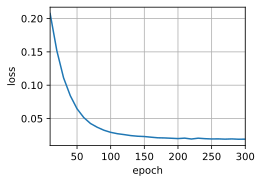

In [18]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 300, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers,
                        dropout)
decoder = Seq2SeqDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers,
                        dropout)
net = d2l.EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

### 预测

为了采用一个接着一个词元的方式预测输出序列， 每个解码器当前时间步的输入都将来自于前一时间步的预测词元。 与训练类似，序列开始词元（“<bos>”） 在初始时间步被输入到解码器中。 该预测过程如下所示， 当输出序列的预测遇到序列结束词元（“<eos>”）时，预测就结束了。

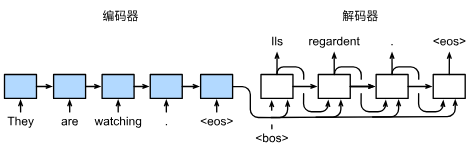

In [19]:
def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps,
                    device, save_attention_weights=False):
    """序列到序列模型的预测"""
    # 在预测时将net设置为评估模式
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [
        src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    src_tokens = d2l.truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    # 添加批量轴
    enc_X = torch.unsqueeze(
        torch.tensor(src_tokens, dtype=torch.long, device=device), dim=0)
    enc_outputs = net.encoder(enc_X, enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)
    # 添加批量轴
    dec_X = torch.unsqueeze(torch.tensor(
        [tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
    output_seq, attention_weight_seq = [], []
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)
        # 我们使用具有预测最高可能性的词元，作为解码器在下一时间步的输入
        dec_X = Y.argmax(dim=2)
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()
        # 保存注意力权重（稍后讨论）
        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)
        # 一旦序列结束词元被预测，输出序列的生成就完成了
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq

### 预测序列的评估

我们可以通过与真实的标签序列进行比较来评估预测序列，虽然 (Papineni et al., 2002) 提出的BLEU（bilingual evaluation understudy） 最先是用于评估机器翻译的结果， 但现在它已经被广泛用于测量许多应用的输出序列的质量。 原则上说，对于预测序列中的任意n元语法（n-grams）， BLEU的评估都是这个n元语法是否出现在标签序列中。

我们将BLEU定义为：$$\exp\left(\min\left(0,1-\frac{\text{len}_{\text{label}}}{\text{len}_{\text{pred}}}\right)\right)\prod_{n=1}^kp_n^{1/2^n},$$ 其中$\mathrm{len}_{\mathrm{label}}$表示标签序列中的词元数和 $\mathrm{len}_{\mathrm{pred}}$表示预测序列中的词元数， k是用于匹配的最长的n元语法。 另外，用$P_{n}$表示n元语法的精确度，它是两个数量的比值： 第一个是预测序列与标签序列中匹配的n元语法的数量， 第二个是预测序列中n元语法的数量的比率。

当预测序列与标签序列完全相同时，BLEU为1 此外，由于元语法越长则匹配难度越大， 所以BLEU为更长的n元语法的精确度分配更大的权重。

BLEU的代码实现如下。

In [20]:
def bleu(pred_seq, label_seq, k):
    """计算bleu"""
    pred_tokens,label_tokens = pred_seq.split(' '),label_seq.split(' ')
    len_pred,len_label = len(pred_tokens),len(label_tokens)
    score = math.exp(min(0,1 - len_label/len_pred))
    for n in range(1,k+1):
        num_matchs,label_subs = 0,collections.defaultdict(int)
        for i in range(len_label-n+1):
            label_subs[' '.join(label_tokens[i:i+n])] += 1
        for i in range(len_pred-n+1):
            if label_subs[' '.join(pred_tokens[i:i+n])] > 0:
                num_matchs += 1
                label_subs[' '.join(pred_tokens[i:i+n])] -= 1
        score *= math.pow(num_matchs / (len_pred - n + 1), math.pow(0.5, n))
    return score

In [21]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, attention_weight_seq = predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

go . => va <unk> bon vu vu vu vu vu vu vu, bleu 0.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est mouillé !, bleu 0.537
i'm home . => je suis chez moi gagné ., bleu 0.803


## 小结
根据“编码器-解码器”架构的设计， 我们可以使用两个循环神经网络来设计一个序列到序列学习的模型。

在实现编码器和解码器时，我们可以使用多层循环神经网络。

我们可以使用遮蔽来过滤不相关的计算，例如在计算损失时。

在“编码器－解码器”训练中，强制教学方法将原始输出序列（而非预测结果）输入解码器。

BLEU是一种常用的评估方法，它通过测量预测序列和标签序列之间的n元语法的匹配度来评估预测。